2.1 理论计算题

**1. 非线性激活函数的重要性**  
证明：  
给定 $\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$，$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$。  
代入得：  
$$
\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)
$$  
定义 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$，则 $\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$，这是一个单层线性网络。因此，没有非线性激活函数的隐藏层无法提高模型表达能力。

**2. 激活函数性质**  
$$
\operatorname{Sigmoid}(x) = \frac{1}{1+e^{-x}}, \quad \operatorname{Sigmoid}'(x) = \operatorname{Sigmoid}(x)\,(1-\operatorname{Sigmoid}(x))
$$  
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}, \quad \tanh'(x) = 1 - \tanh^2(x)
$$

2.2 编程题

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

batch_size = 256
hidden_size = 256
epochs = 10
lr = 0.1

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

input_size = 784
num_classes = 10
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, num_classes) * 0.01
b2 = torch.zeros(num_classes)
params = [W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

def relu(x):
    return torch.maximum(x, torch.zeros_like(x))

def cross_entropy_softmax(logits, y):
    exp_logits = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        h = relu(X @ W1 + b1)
        o = h @ W2 + b2
        loss = cross_entropy_softmax(o, y)
        total_loss += loss.item()
        loss.backward()
        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

def evaluate():
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            h = relu(X @ W1 + b1)
            o = h @ W2 + b2
            pred = o.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    print(f"Test accuracy: {correct/total:.4f}")

evaluate()

100.0%
100.0%
100.0%
100.0%


Epoch 1, Loss: 1.0409
Epoch 2, Loss: 0.6003
Epoch 3, Loss: 0.5224
Epoch 4, Loss: 0.4799
Epoch 5, Loss: 0.4562
Epoch 6, Loss: 0.4361
Epoch 7, Loss: 0.4176
Epoch 8, Loss: 0.4051
Epoch 9, Loss: 0.3931
Epoch 10, Loss: 0.3826
Test accuracy: 0.8495


3.1 理论计算题

**1. 过拟合与欠拟合**  
- **训练误差**：模型在训练数据集上的平均损失。  
- **泛化误差**：模型在未知测试数据上的期望损失。  
- 当训练误差极低但泛化误差高时，模型处于**过拟合**状态。  
- 控制模型复杂度的方法：减少层数/神经元数、L2正则化、Dropout、早停、增加数据量。

**2. K折交叉验证算法步骤**  
1. 将数据集随机划分成K个大小相等的子集。  
2. 对每个子集 \(i=1..K\)：  
   - 将第i个子集作为验证集，其余K-1个子集合并作为训练集。  
   - 在训练集上训练模型，在验证集上评估性能（如准确率、MSE）。  
3. 计算K次评估指标的平均值作为模型的最终性能估计。

3.2 编程题

=== 无正则化 ===
Epoch 100: train loss 0.0000, val loss 30.0817
Epoch 200: train loss 0.0000, val loss 30.0817
Epoch 300: train loss 0.0000, val loss 30.0817
Epoch 400: train loss 0.0000, val loss 30.0817
Epoch 500: train loss 0.0000, val loss 30.0818

=== 权重衰减 (λ=0.01) ===
Epoch 100: train loss 0.0001, val loss 33.0654
Epoch 200: train loss 0.0001, val loss 33.0315
Epoch 300: train loss 0.0001, val loss 32.9966
Epoch 400: train loss 0.0000, val loss 32.9583
Epoch 500: train loss 0.0001, val loss 32.9192

=== Dropout (p=0.5) ===
Epoch 100: train loss 1.8597, val loss 34.3420
Epoch 200: train loss 0.9116, val loss 33.2881
Epoch 300: train loss 1.0257, val loss 32.6998
Epoch 400: train loss 1.6033, val loss 31.7290
Epoch 500: train loss 1.0976, val loss 31.9819


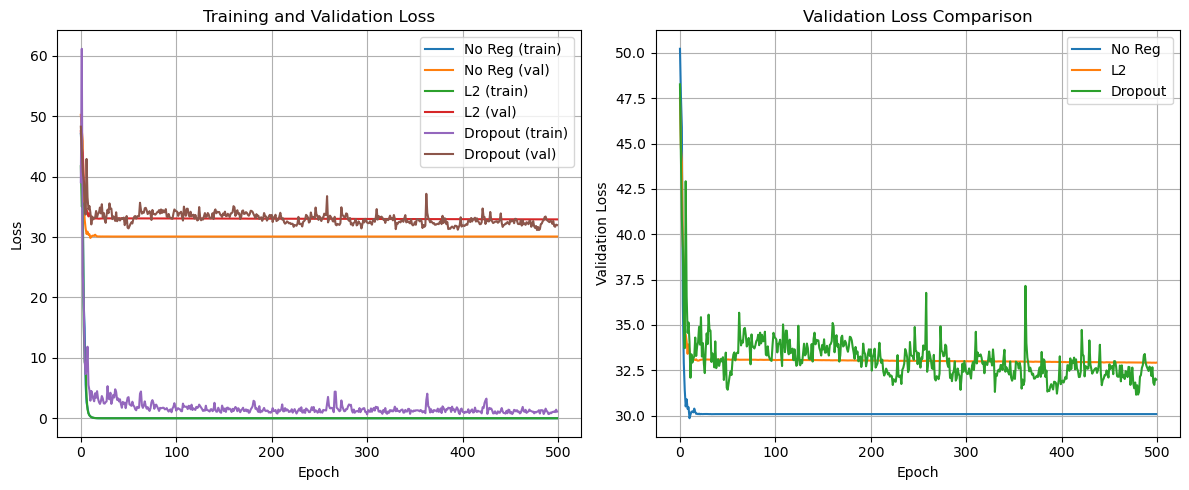


最终验证损失 (No Reg): 30.0818
最终验证损失 (L2): 32.9192
最终验证损失 (Dropout): 31.9819


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 构造高维多项式过拟合数据：样本少，特征维度高
n_train, n_val = 100, 50
input_dim = 200
hidden_dim = 256
output_dim = 1
epochs = 500
lr = 0.01
batch_size = 32

# 生成真实权重（稀疏）
true_w = torch.randn(input_dim, 1) * 0.5
X_train = torch.randn(n_train, input_dim)
y_train = X_train @ true_w + 0.1 * torch.randn(n_train, 1)
X_val = torch.randn(n_val, input_dim)
y_val = X_val @ true_w + 0.1 * torch.randn(n_val, 1)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# 定义模型（单隐藏层MLP）
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 训练函数
def train_model(model, weight_decay, train_loader, val_loader, epochs, lr):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        
        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}: train loss {train_losses[-1]:.4f}, val loss {val_losses[-1]:.4f}")
    return train_losses, val_losses

# 1. 无正则化
model1 = MLP(input_dim, hidden_dim, output_dim, dropout=0.0)
print("=== 无正则化 ===")
train_loss1, val_loss1 = train_model(model1, weight_decay=0.0, train_loader=train_loader, 
                                     val_loader=val_loader, epochs=epochs, lr=lr)

# 2. 权重衰减 (L2正则化)
model2 = MLP(input_dim, hidden_dim, output_dim, dropout=0.0)
print("\n=== 权重衰减 (λ=0.01) ===")
train_loss2, val_loss2 = train_model(model2, weight_decay=0.01, train_loader=train_loader,
                                     val_loader=val_loader, epochs=epochs, lr=lr)

# 3. Dropout (p=0.5)
model3 = MLP(input_dim, hidden_dim, output_dim, dropout=0.5)
print("\n=== Dropout (p=0.5) ===")
train_loss3, val_loss3 = train_model(model3, weight_decay=0.0, train_loader=train_loader,
                                     val_loader=val_loader, epochs=epochs, lr=lr)

# 绘制对比曲线
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss1, label='No Reg (train)')
plt.plot(val_loss1, label='No Reg (val)')
plt.plot(train_loss2, label='L2 (train)')
plt.plot(val_loss2, label='L2 (val)')
plt.plot(train_loss3, label='Dropout (train)')
plt.plot(val_loss3, label='Dropout (val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(val_loss1, label='No Reg')
plt.plot(val_loss2, label='L2')
plt.plot(val_loss3, label='Dropout')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 打印最终验证损失对比
print(f"\n最终验证损失 (No Reg): {val_loss1[-1]:.4f}")
print(f"最终验证损失 (L2): {val_loss2[-1]:.4f}")
print(f"最终验证损失 (Dropout): {val_loss3[-1]:.4f}")

4.1 理论计算题

**1. 梯度消失与梯度爆炸**  
- 梯度反向传播涉及多层雅可比矩阵连乘 \(\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}\)。  
- 若每层的雅可比矩阵的最大奇异值 \(>1\)，连乘后梯度指数增长 → **梯度爆炸**；若 \(<1\) → **梯度消失**。  
- 激活函数如Sigmoid，其导数最大为0.25，多层累乘极易小于1，导致梯度消失。

**2. ReLU缓解梯度消失**  
ReLU在正半轴导数为1，负半轴为0。正向传播时，若神经元激活，梯度可直接无损传回，不衰减；且不会饱和，避免导数为0。因此深层网络也能保持有效梯度。

4.2 编程题

In [3]:
import torch
import torch.nn as nn
import torch.nn.init as init
from functools import partial

class DeepNet(nn.Module):
    def __init__(self, activation=nn.Sigmoid, init_func=init.normal_):
        super().__init__()
        layers = []
        for _ in range(20):
            layers.append(nn.Linear(256, 256))
            layers.append(activation())
        self.net = nn.Sequential(*layers)
        # 注意：这里只传递 weight 张量，不再传递 mean/std
        self.apply(lambda m: init_func(m.weight) if isinstance(m, nn.Linear) else None)
    
    def forward(self, x):
        return self.net(x)

# ========== 1. 模拟梯度消失（Sigmoid + 标准初始化，std=1） ==========
# 使用 partial 将 mean=0, std=1 绑定到 init.normal_
model = DeepNet(activation=nn.Sigmoid, init_func=partial(init.normal_, mean=0, std=1))
x = torch.randn(64, 256)
out = model(x)
loss = out.sum()
loss.backward()
print("=== 梯度消失情况 (Sigmoid + std=1) ===")
for i, layer in enumerate(model.net):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2} grad norm: {grad_norm:.6f}")  # 后几层梯度会非常小

# ========== 2. 梯度爆炸（ReLU + 大初始化 std=10） ==========
model = DeepNet(activation=nn.ReLU, init_func=partial(init.normal_, mean=0, std=10))
x = torch.randn(64, 256)
out = model(x)
loss = out.sum()
loss.backward()  # 可能出现 NaN 或极大梯度
print("\n=== 梯度爆炸情况 (ReLU + std=10) ===")
for i, layer in enumerate(model.net):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2} grad norm: {grad_norm:.6f}")  # 某些层梯度可能为 nan 或极大

# ========== 3. Xavier 初始化 + ReLU（稳定） ==========
model = DeepNet(activation=nn.ReLU, init_func=init.xavier_uniform_)  # Xavier 不需要额外参数
x = torch.randn(64, 256)
out = model(x)
loss = out.sum()
loss.backward()
print("\n=== 稳定情况 (Xavier + ReLU) ===")
for i, layer in enumerate(model.net):
    if isinstance(layer, nn.Linear):
        grad_norm = layer.weight.grad.norm().item()
        print(f"Layer {i//2} grad norm: {grad_norm:.6f}")  # 应在 1e-6 到 1e3 之间

=== 梯度消失情况 (Sigmoid + std=1) ===
Layer 0 grad norm: 9530.492188
Layer 1 grad norm: 6047.366699
Layer 2 grad norm: 5121.242676
Layer 3 grad norm: 4069.536621
Layer 4 grad norm: 3234.286377
Layer 5 grad norm: 2659.962891
Layer 6 grad norm: 1958.353638
Layer 7 grad norm: 1412.909058
Layer 8 grad norm: 1060.068604
Layer 9 grad norm: 953.018311
Layer 10 grad norm: 758.112610
Layer 11 grad norm: 671.602478
Layer 12 grad norm: 571.367737
Layer 13 grad norm: 516.542847
Layer 14 grad norm: 542.052551
Layer 15 grad norm: 584.163269
Layer 16 grad norm: 561.351929
Layer 17 grad norm: 537.393433
Layer 18 grad norm: 679.739441
Layer 19 grad norm: 570.656372

=== 梯度爆炸情况 (ReLU + std=10) ===
Layer 0 grad norm: nan
Layer 1 grad norm: inf
Layer 2 grad norm: inf
Layer 3 grad norm: inf
Layer 4 grad norm: inf
Layer 5 grad norm: inf
Layer 6 grad norm: inf
Layer 7 grad norm: inf
Layer 8 grad norm: inf
Layer 9 grad norm: inf
Layer 10 grad norm: inf
Layer 11 grad norm: inf
Layer 12 grad norm: inf
Layer 13 grad 

5.1 理论计算题

**协变量偏移与标签偏移的区别与联系**  
- **协变量偏移**：特征分布改变 \(p(x) \neq q(x)\)，但条件分布相同 \(p(y|x)=q(y|x)\)。  
  例子：训练数据中猫的图像多为白天拍摄，测试多为夜晚拍摄（光照分布改变），但识别规则不变。  
- **标签偏移**：标签分布改变 \(p(y) \neq q(y)\)，但似然相同 \(p(x|y)=q(x|y)\)。  
  例子：训练时某一疾病的发病率高，测试时发病率低，但症状与疾病的关系不变。  
- **联系**：两者都是训练与测试分布不一致的特殊情况，均可通过样本重加权（如利用倾向得分）进行纠正。区别在于偏移发生的边际变量不同。

5.2 编程题

In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression

# 1. 生成数据
np.random.seed(42)
n_train, n_test = 1000, 500
x_train = np.random.normal(-1, 1, size=(n_train, 1))
y_train = 2 * x_train + 0.1 * np.random.randn(n_train, 1)  # 形状 (1000,1)
x_test = np.random.normal(2, 1, size=(n_test, 1))
y_test = 2 * x_test + 0.1 * np.random.randn(n_test, 1)      # 形状 (500,1)

# 2. 基线模型：普通线性回归
lr = LinearRegression()
lr.fit(x_train, y_train)
mse_baseline = np.mean((lr.predict(x_test) - y_test)**2)
print(f"Baseline MSE: {mse_baseline:.4f}")

# 3. 训练区分训练/测试集的分类器（逻辑回归）
X_combined = np.vstack([x_train, x_test])
y_combined = np.array([0]*n_train + [1]*n_test)   # 0: train, 1: test
clf = LogisticRegression()
clf.fit(X_combined, y_combined)
prob_test = clf.predict_proba(x_train)[:, 1]      # P(test | x_train)
weights = prob_test / (1 - prob_test)             # P(test)/P(train)
# 可选：归一化权重（不影响结果，但数值稳定）
weights = weights / weights.sum() * n_train

# 4. 加权线性回归
# 添加截距列
X_train_aug = np.hstack([x_train, np.ones((n_train, 1))])   # 形状 (1000,2)
X_test_aug = np.hstack([x_test, np.ones((n_test, 1))])       # 形状 (500,2)   <-- 这里补上定义
y_train = y_train.ravel()  # 确保一维，避免后面维度问题

# 加权最小二乘解
W = np.diag(weights)                       # (1000,1000) 对角矩阵
theta = np.linalg.inv(X_train_aug.T @ W @ X_train_aug) @ X_train_aug.T @ W @ y_train
y_pred_weighted = X_test_aug @ theta
mse_weighted = np.mean((y_pred_weighted - y_test.ravel())**2)
print(f"Weighted MSE: {mse_weighted:.4f}")
print(f"Improvement: {mse_baseline - mse_weighted:.4f}")

Baseline MSE: 0.0102
Weighted MSE: 0.0240
Improvement: -0.0138
